# A living map, animated

Rows arrive in time order. A map is fitted once, on the first rows, and
every later batch is placed into that map as it arrives. When enough new
rows have been placed, the map is refitted over everything so far, and the
new layout is aligned to the old one so the animation does not jump. The
result is a map that grows with the data, drawn as an animation.

This is the method behind the foreign-exchange animation in the README,
which folds thirty years of trading sessions into one map. Here it runs on
a synthetic stream of 1,500 rows so that it finishes in about a minute on a
laptop.

What you need: the UltraDim wheel, `matplotlib` and `pillow`. The UMAP
fits need a GPU (Metal on macOS, Vulkan on Linux). `ffmpeg` on the path
adds an MP4 beside the GIF; without it you get the GIF alone.

This file is a Python script and a notebook. Run it as a script, and the
animation is written to disk. Open it as a notebook, with
`jupytext --to ipynb 04_living_map_animation.py`, and the animation is
shown inline as well.

In [1]:
import json
import math
import os
import shutil
import subprocess
import tempfile

import numpy as np
import ultradim

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image


def in_notebook():
    """True inside a Jupyter kernel, False when run as a script."""
    try:
        from IPython import get_ipython
        return type(get_ipython()).__name__ == "ZMQInteractiveShell"
    except ImportError:
        return False


IN_NOTEBOOK = in_notebook()
if IN_NOTEBOOK:
    from IPython.display import Image as NotebookImage, Video, display

print("wheel version:", ultradim.__version__, "| notebook:", IN_NOTEBOOK)

wheel version: 0.4.0 | notebook: True


## 1. The stream

Every row is sparse: 32 non-zeros in a space of 20,000 dimensions. Twenty
topics are planted. Each topic owns a pool of 36 dimensions, and a row
draws 30 of its non-zeros from its topic's pool, so rows of one topic are
neighbours by construction and the map has something to find.

The mixture drifts. Every topic is present on every day, and on top of
that a moving preference favours the low topics early in the stream and
the high topics late. That is the shape of a real stream: the populations
a map was fitted on are not the populations that arrive later. The
animation shows what the map does about it.

In [2]:
N_DAYS = 1_500        # one row per "day"
BASE = 600            # rows in the first map
FOLD = 30             # rows folded in per step
SOURCE_DIM = 20_000   # width of the sparse space
NNZ = 32              # non-zeros per row
TOPICS = 20           # planted structure: each row draws most of its
                      # non-zeros from its topic's pool of 36 dimensions
FPS = 6
OUT = "living_map.gif"


def planted_stream(seed=7):
    """Rows whose topic mixture drifts over time: early days favour the low
    topics, late days the high ones, so the map's populations shift."""
    rng = np.random.default_rng(seed)
    pools = [rng.choice(SOURCE_DIM, 36, replace=False) for _ in range(TOPICS)]
    rows, topics = [], []
    for day in range(N_DAYS):
        # every topic is always present; on top of that a drifting preference
        # moves through the topics over time, so the populations shift
        if rng.random() < 0.6:
            t = int(rng.integers(TOPICS))
        else:
            centre = TOPICS * day / N_DAYS
            t = int(np.clip(round(rng.normal(centre, 3.0)), 0, TOPICS - 1))
        own = rng.choice(pools[t], 30, replace=False)
        noise = rng.choice(SOURCE_DIM, NNZ - 30, replace=False)
        idx = np.unique(np.concatenate([own, noise]))
        val = rng.random(len(idx)).astype(np.float32) + 0.2
        val /= np.linalg.norm(val)
        rows.append({"indices": [int(i) for i in idx], "values": [float(v) for v in val]})
        topics.append(t)
    return rows, np.array(topics)


rows, topics = planted_stream()
print(f"{N_DAYS} rows, {NNZ} non-zeros each, {TOPICS} topics")
print("topic counts in the first 300 days:", np.bincount(topics[:300], minlength=TOPICS).tolist())
print("topic counts in the last 300 days :", np.bincount(topics[-300:], minlength=TOPICS).tolist())

1500 rows, 32 non-zeros each, 20 topics
topic counts in the first 300 days: [58, 20, 25, 17, 25, 14, 20, 5, 10, 11, 11, 7, 5, 15, 10, 4, 10, 12, 10, 11]
topic counts in the last 300 days : [9, 11, 9, 7, 12, 7, 11, 8, 13, 9, 12, 19, 11, 11, 10, 15, 20, 28, 21, 57]


## 2. Calling the engine

Every operation is one call: the RPC's name and its fields as JSON. The
answer comes back as JSON. A failed call carries an `error_message` that
says what to fix, so the helper below raises it as an exception rather
than letting a bad answer travel on.

The database runs inside this process, in a directory on disk. There is no
server to start.

In [3]:
def rpc(db, rpc_name, **fields):
    out = json.loads(db.call_json(rpc_name, json.dumps(fields)))
    if isinstance(out, dict) and out.get("error_message"):
        raise RuntimeError(f"{rpc_name}: {out['error_message']}")
    return out


work = tempfile.mkdtemp(prefix="ultradim_living_map_")
frames_dir = os.path.join(work, "frames")
os.makedirs(frames_dir)
db = ultradim.UltraDim(os.path.join(work, "db"))
fam = "stream"
print("database at", os.path.join(work, "db"))

database at /var/folders/9b/z0rm6nz12p1d0f8k1rmnbkrm0000gn/T/ultradim_living_map_bp06j6l1/db


## 3. One family, every row, one index

A family holds rows of one width. This one is sparse, 20,000 wide, and
`max_nnz_per_row` is set from the data with ten percent of headroom. The
other settings, `projection_dim` and `seeds`, are the index's settings;
the tuning guide covers how to choose them, and the values here are the
ones the other examples use.

All 1,500 rows go in now, in one batch, and the index is built once. The
maps that follow are built over subsets of these rows by row id, so the
stream is simulated by which rows a map is allowed to see, not by when
rows are inserted.

In [4]:
max_nnz = math.ceil(1.10 * max(len(r["indices"]) for r in rows))
rpc(db, "CreateUltradimV23Collection", name=fam, source_dim=SOURCE_DIM,
    projection_dim=128, seeds=[11, 22, 33, 44], sparse_substrate=True,
    max_nnz_per_row=max_nnz)
for start in range(0, N_DAYS, 1000):
    batch = rows[start:start + 1000]
    rpc(db, "UpsertUltradimV23Points", name=fam,
        batch={"row_ids": list(range(start, start + len(batch))), "sparse_vectors": batch})
built = rpc(db, "BuildUltradimV23TrellisIndex", name=fam)
print(f"family: {N_DAYS} rows, indexed, {built['graph_nodes']} nodes")

family: 1500 rows, indexed, 1500 nodes


## 4. The base map

A UMAP map is fitted on a neighbour graph, so the graph comes first. The
graph is built over the first 600 rows with `k=12` neighbours per row.
`oracle_sample=200` asks the engine to check its own work: for 200 rows it
computes the exact neighbours by brute force and reports the fraction the
graph found, as `measured_recall_at_k`. A map refuses to fit on a graph
whose measured recall is below 0.99, so a bad graph cannot become a
plausible-looking map.

The fit is deterministic given `umap_seed`. Run this twice and the
positions are the same.

In [5]:
graph = rpc(db, "BuildUltradimV23KnnGraph", name=fam, k=12, oracle_sample=200, top_m=1600,
            row_ids=list(range(BASE)))
fit = rpc(db, "FitUltradimV23Umap", name=fam, graph_id=graph["graph_id"],
          n_components=2, n_neighbors=12, deterministic=True, umap_seed=174)
uid = fit["umap_id"]
print(f"base map on {BASE} rows: graph recall {graph.get('measured_recall_at_k'):.4f}")
lineage = [(BASE, uid, "base")]

base map on 600 rows: graph recall 0.9971


## 5. Folding the stream in

Each step takes the next 30 rows and places them into the existing map
with `IncrementalFitUltradimV23Umap`. The call returns a child map that
holds every row so far. The parent is retained, so the lineage of maps is
the history of the stream, and every retained map can be drawn later.

Placement is fast, and placement is not a refit: the rows already on the
map do not move, and the new rows are put where their neighbours are. As
the stream drifts, the fitted map describes the arrivals less and less
well. The tolerance used here is one fifth: when the rows placed since
the last full fit exceed a fifth of that fit, the map is refitted over
everything so far, and folding continues from the new map. The tuning
guide's section on incremental UMAP covers how to score arrivals and when
to rebuild; this is the simplest version of that procedure.

The fold's answer reports each batch's own share of the fitted corpus as
`staleness_fraction`. The running total that decides a refit is kept
here.

In [6]:
fitted, folded_since = BASE, 0
for f0 in range(BASE, N_DAYS, FOLD):
    f1 = min(f0 + FOLD, N_DAYS)
    ids = list(range(f0, f1))
    inc = rpc(db, "IncrementalFitUltradimV23Umap", name=fam, parent_umap_id=uid,
              sparse_queries=[rows[i] for i in ids], batch_row_ids=ids, persist=True,
              top_m=1600)
    uid = inc["child_umap_id"]
    lineage.append((f1, uid, "fold"))
    folded_since += len(ids)
    if folded_since > 0.2 * fitted:
        g2 = rpc(db, "BuildUltradimV23KnnGraph", name=fam, k=12, oracle_sample=200,
                 top_m=1600, row_ids=list(range(f1)))
        u2 = rpc(db, "FitUltradimV23Umap", name=fam, graph_id=g2["graph_id"],
                 n_components=2, n_neighbors=12, deterministic=True, umap_seed=174)
        uid = u2["umap_id"]
        lineage.append((f1, uid, "refit"))
        print(f"day {f1}: {folded_since} rows folded since a fit of {fitted}, "
              f"refitted over {f1} rows, graph recall {g2.get('measured_recall_at_k'):.4f}")
        fitted, folded_since = f1, 0
folds = sum(1 for _, _, k in lineage if k == "fold")
refits = sum(1 for _, _, k in lineage if k == "refit")
print(f"lineage: {folds} folds, {refits} refits, {len(lineage)} maps retained")

day 750: 150 rows folded since a fit of 600, refitted over 750 rows, graph recall 1.0000
day 930: 180 rows folded since a fit of 750, refitted over 930 rows, graph recall 1.0000
day 1140: 210 rows folded since a fit of 930, refitted over 1140 rows, graph recall 1.0000
day 1380: 240 rows folded since a fit of 1140, refitted over 1380 rows, graph recall 1.0000
lineage: 30 folds, 4 refits, 35 maps retained


## 6. Reading every map back, and aligning the maps

`GetUltradimV23UmapEmbedding` pages through a map's positions, two numbers
per row. Each map in the lineage is read back in full.

A UMAP layout is defined up to rotation and translation: two fits of the
same data can be the same shape at a different angle. Left as they are,
the refit frames of the animation would spin. So each layout is aligned
to the layout before it by the rigid transform, rotation and translation
with no scaling, that best matches the rows the two maps share. This is
for the drawing only. The positions stored in the engine are untouched.

In [7]:
def fetch_layout(db, fam, umap_id):
    """Every row's 2-D position on one map, as {row_id: (x, y)}."""
    pos, off = {}, 0
    while True:
        page = rpc(db, "GetUltradimV23UmapEmbedding", name=fam, umap_id=umap_id,
                   limit=8192, offset_ordinal=off)
        emb, nc = page["embeddings"], page["n_components"]
        if not emb:
            break
        for i in range(0, len(emb), nc):
            pos[off + i // nc] = (emb[i], emb[i + 1])
        nxt = page.get("next_offset_ordinal")
        if nxt is None or nxt <= off:
            break
        off = nxt
    return pos


def align(prev, cur):
    """Rigid transform (rotation and translation, no scaling, no reflection)
    that best maps the rows `cur` shares with `prev` onto their `prev`
    positions."""
    keys = [k for k in cur if k in prev]
    if len(keys) < 8:
        return cur
    a = np.array([prev[k] for k in keys])
    b = np.array([cur[k] for k in keys])
    am, bm = a.mean(0), b.mean(0)
    u, _, vt = np.linalg.svd((b - bm).T @ (a - am))
    d = np.sign(np.linalg.det(u @ vt)) or 1.0
    r = u @ np.diag([1.0, d]) @ vt
    return {k: tuple((np.array(v) - bm) @ r + am) for k, v in cur.items()}


base_layout = fetch_layout(db, fam, lineage[0][1])
print(f"base map: {len(base_layout)} rows, first row at "
      f"({base_layout[0][0]:.2f}, {base_layout[0][1]:.2f})")

base map: 600 rows, first row at (0.32, 8.19)


## 7. Drawing the frames

One frame per retained map. Rows are coloured by topic. The rows placed
in the latest fold are drawn larger with a black edge, so you can see
where each batch went. The axes grow with the map and never shrink, so
a frame's scale means the same thing as the frame before it.

In [8]:
def render(layout, upto, topics, title, new_ids, path, lims):
    ids = sorted(i for i in layout if i < upto)
    xs = [layout[i][0] for i in ids]
    ys = [layout[i][1] for i in ids]
    pad = 0.08
    box = (min(xs), max(xs), min(ys), max(ys))
    if not lims:
        lims.extend(box)
    else:
        lims[0] = min(lims[0], box[0]); lims[1] = max(lims[1], box[1])
        lims[2] = min(lims[2], box[2]); lims[3] = max(lims[3], box[3])
    sx = (lims[1] - lims[0]) or 1.0
    sy = (lims[3] - lims[2]) or 1.0
    cmap = plt.get_cmap("viridis")
    fig, ax = plt.subplots(figsize=(6, 6), dpi=90)
    ax.scatter(xs, ys, s=5, c=[cmap(topics[i] / (TOPICS - 1)) for i in ids], linewidths=0, alpha=0.8)
    nw = [i for i in new_ids if i in layout]
    if nw:
        ax.scatter([layout[i][0] for i in nw], [layout[i][1] for i in nw], s=30,
                   c=[cmap(topics[i] / (TOPICS - 1)) for i in nw], edgecolors="black", linewidths=0.6)
    ax.set_xlim(lims[0] - pad * sx, lims[1] + pad * sx)
    ax.set_ylim(lims[2] - pad * sy, lims[3] + pad * sy)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=9)
    fig.text(0.02, 0.02, f"day {upto:4d}", fontsize=14, family="monospace", fontweight="bold")
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    fig.savefig(path)
    plt.close(fig)


lims, frame_paths = [], []
reference = prev = base_layout
first = os.path.join(frames_dir, "f0000.png")
render(reference, BASE, topics, "base map", [], first, lims)
frame_paths.append(first)
for n, (upto, mid, kind) in enumerate(lineage[1:], start=1):
    raw = fetch_layout(db, fam, mid)
    if kind == "refit":
        reference = align(prev, raw)
        layout = reference
        title = f"refit over {upto} rows, aligned to the previous frame"
        new = []
    else:
        layout = align(reference, raw)
        title = "fold: the new rows placed, the rest held"
        new = range(upto - FOLD, upto)
    path = os.path.join(frames_dir, f"f{n:04d}.png")
    render(layout, upto, topics, title, new, path, lims)
    frame_paths.append(path)
    prev = layout
print(f"{len(frame_paths)} frames drawn")

35 frames drawn


## 8. The animation

The frames become a GIF, and an MP4 if `ffmpeg` is installed. As a script
this cell writes the files and stops. As a notebook it shows them here.

wrote living_map.gif: 35 frames, 269 KB
wrote living_map.mp4


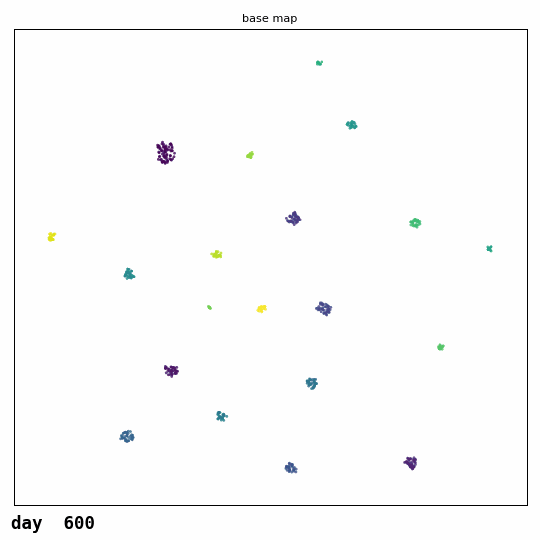

In [9]:
frames = [Image.open(p).convert("P", palette=Image.ADAPTIVE) for p in frame_paths]
frames[0].save(OUT, save_all=True, append_images=frames[1:], duration=int(1000 / FPS), loop=0)
print(f"wrote {OUT}: {len(frames)} frames, {os.path.getsize(OUT) // 1024} KB")
mp4 = None
if shutil.which("ffmpeg"):
    mp4 = OUT.replace(".gif", ".mp4")
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-framerate", str(FPS),
                    "-i", os.path.join(frames_dir, "f%04d.png"), "-c:v", "libx264",
                    "-pix_fmt", "yuv420p", "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2", mp4],
                   check=True)
    print(f"wrote {mp4}")
if IN_NOTEBOOK:
    display(NotebookImage(filename=OUT))
    if mp4:
        display(Video(mp4, embed=True))

## 9. What to look for

In the fold frames the existing points hold still and the new rows, with
black edges, appear among their topic. Early in the stream they appear
in the low-topic groups; late in the stream, in the high-topic groups.
That is the drift, made visible one batch at a time.

At each refit the whole map is redrawn over every row so far, and the
alignment keeps it in place, so the shapes settle rather than spin. A
population that was thin at the base fit is well formed after a refit
that included it.

The lineage is a record. Every retained map can be read back, so the
history of the stream is a history of maps, and the difference between a
fold's placement and the next refit's is a measure of how far the data
has moved. The tuning guide's section on incremental UMAP gives the
procedure for scoring arrivals and deciding when to rebuild; the
foreign-exchange animation in the README is this procedure on thirty
years of real data.

In [10]:
shutil.rmtree(work, ignore_errors=True)
print("temporary database removed; the animation stays at", OUT)

temporary database removed; the animation stays at living_map.gif
